In [1]:
import numpy as np
from galpy.orbit import Orbit
from galpy.potential import KeplerPotential
import astropy.constants as acon
import astropy.units as u
import matplotlib.pyplot as plt

In [2]:
from scipy.spatial.transform import Rotation
from numpy.linalg import norm
from scipy.integrate import quad

In [3]:
num = 10000
t = 0
rs = 149600000

v_sun = np.array([12.9, 245.6, 7.78])
v_earth = np.array([0, 0, 0])
v_str = np.array([10, 0, 0])
v_c = v_str #- v_sun

normal = np.array([-v_c[1], v_c[0], 0])
rot = Rotation.from_rotvec(t * normal / norm(normal))
r = rot.apply(v_c)
r = r / norm(r) * rs



In [4]:
num = 50
points = []

dist = 1.5

z = np.linspace(-dist, dist, num) * rs * u.km
y = np.linspace(-dist, dist, num) * rs * u.km
x = 20 * rs * u.km

rho = np.sqrt(x*x + y*y)
phi = np.arctan(y/x)

for i in range(num):
    for j in range(num):
        sp = [x.value, y[j].value, z[i].value]
        vx = np.sqrt(acon.GM_sun * 2/ np.linalg.norm(np.array(sp)) / u.km) 
        vx = -35 * u.km / u.s
        
        vR = vx*  np.cos(phi[j])
        vT = - vx * np.sin(phi[j])
        
        points.append([rho[j], vR.to(u.km / u.s), vT, z[i] , 0 * u.km / u.s, phi[j]])


In [5]:
# 1. Initialize the orbit [R, vR, vT, z, vz, phi]
o = Orbit(points)

# 2. Define a time array for integration

tf = np.sqrt(2 * (np.linalg.norm(sp) * u.km) ** 3 / 3 / acon.GM_sun).to(u.s).value
ts = np.linspace(0*tf, 1 * tf, 100000) * u.s


pot = KeplerPotential(acon.GM_sun)

# 3. Solve the equations of motion
o.integrate(ts, pot)

rs_kpc = (rs * u.km).to(u.kpc).value


(-9.69641163401754e-09, 9.69641163401754e-09)

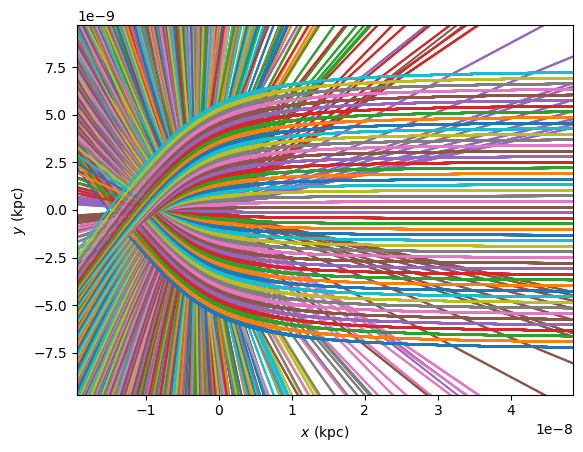

In [6]:
o.plot(d1 = 'x', d2='y')
plt.xlim(-4 * rs_kpc, 10 * rs_kpc)
plt.ylim(-2 * rs_kpc, 2 * rs_kpc)

In [7]:
orbit = o.getOrbit()


In [8]:
z = orbit[:, :, 3]
mask_ri = orbit[:, :, 0]

mask1 = orbit[:, :, -1]

def denPoints(ri, ro, t1, t2, y1, y2):
        
    if t2 > t1:
        dummy = t1
        t1 = t2
        t2 = dummy
        
    
    ro = ((ro*rs * u.km).to(u.kpc) / 8).value
    ri = ((ri*rs * u.km).to(u.kpc) / 8).value
    
    mask_r = (mask_ri < ro) * (mask_ri > ri) * (z < y2) * (z > y1)
    
    #assuming t1 > t2
    if t2 < t1 - np.pi:
        if t2 < 0 and t1 > 0:
            print('o', t2, t1)
            print((((mask1 <= t2) + (mask1 >= t1)) * mask_r).sum())
            return (((mask1 <= t2) + (mask1 >= t1)) * mask_r).sum()
        else: 
            print('oj')
            return ((mask1 <= t2) * (mask1 >= t1) * mask_r).sum()
    else:
        return ((mask1 <= t1) * (mask1 >= t2) * mask_r).sum()

In [9]:
#first = denPoints(9.8, 10, np.pi/20, -np.pi/20, -5, 5)
y1 = ((0.1 * rs * u.km).to(u.kpc) / 8).value

second = denPoints(0.9, 1.1, np.pi/60 + np.pi, -np.pi/60 + np.pi, -y1, y1)
second

np.int64(18396)

-3.089232776029964
3.089232776029963
o -3.0368728984701336 3.1415926535897927
26760


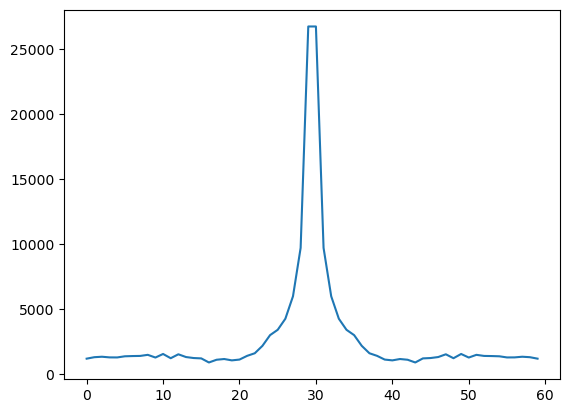

In [16]:
num = 30

def norm(t):
    if t > np.pi:
        return t - np.pi * 2
    if t <= -np.pi:
        return t + np.pi * 2
    
    return t

y1 = ((0.1 * rs * u.km).to(u.kpc) / 8).value

sec = []
for i in range(0, num*2):
    if i == num:
        print(norm(np.pi/num / 2 + i * np.pi / num))
        print(norm(-np.pi/num / 2 + i * np.pi / num))
    second = denPoints(0.9, 1.1, 
                       norm((i+1) * np.pi / num), 
                       norm(i * np.pi / num), -y1, y1)
    sec.append(second)
    
plt.clf()
#sec[num] = sec[num-1]
plt.plot(sec) 



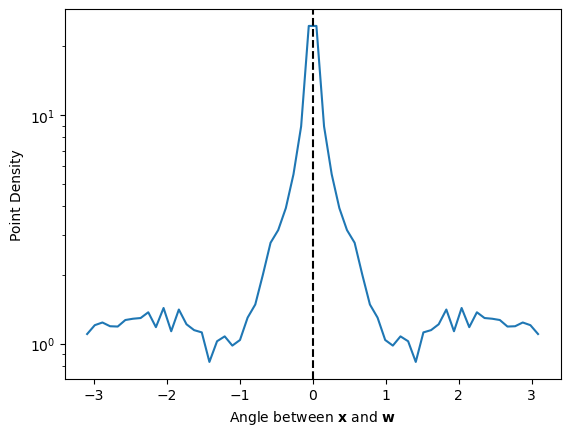

In [21]:
plt.clf()
t = np.arange(np.pi/num/2, np.pi*2, np.pi/num) - np.pi
sec = np.array(sec)
sec = sec / sec[0] * 1.1019062475486319 # normalise to whatever the jacobian says the density at the end should be
plt.semilogy(t, np.array(sec))

plt.ylabel("Point Density")
plt.xlabel("Angle between $\\mathbf{x}$ and $\\mathbf{w}$")
plt.axvline(0, ls="--", c= "black")

In [22]:
# From analyical solution, the value at ang ~ 0.05235987755983018 should be 20.63183794396858
ind = np.argmax(sec)
sec[ind], t[ind]

(np.float64(24.57250932033449), np.float64(-0.05235987755982974))